<a href="https://colab.research.google.com/github/varshiniv-dev/internship-ai/blob/main/case_study_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df= pd.read_csv("/content/movie_ratings_dataset.csv") #to load the cse file
df.head() #display first 5 rows

,Movie_ID,Genre,Duration_Minutes,IMDB_Rating,Box_Office_Millions
0,4001,Thriller,168,6.8,77.3
1,4002,Thriller,155,6.1,132.1
2,4003,Action,125,7.8,276.1
3,4004,Comedy,177,9.5,437.8
4,4005,Action,98,6.2,222.4


In [40]:
# Display the number of rows and columns
print("Shape of dataset:", df.shape)  #row.column

# Display column names
print("\nColumn names:")
print(df.columns)

# Display basic information about the dataset
print("\nDataset information:")
df.info()

Shape of dataset: (20, 5)

Column names:
Index(['Movie_ID', 'Genre', 'Duration_Minutes', 'IMDB_Rating',
       'Box_Office_Millions'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Movie_ID             20 non-null     int64  
 1   Genre                20 non-null     object 
 2   Duration_Minutes     20 non-null     int64  
 3   IMDB_Rating          20 non-null     float64
 4   Box_Office_Millions  20 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 932.0+ bytes


In [41]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Movie_ID               0
Genre                  0
Duration_Minutes       0
IMDB_Rating            0
Box_Office_Millions    0
dtype: int64


In [42]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [43]:
# Display statistical summary of numerical columns
df.describe()

,Movie_ID,Duration_Minutes,IMDB_Rating,Box_Office_Millions
count,20.00000,20.000000,20.000000,20.000000
mean,4010.50000,137.100000,7.210000,278.850000
std,5.91608,28.252434,1.224272,134.341272
min,4001.00000,95.000000,5.200000,35.900000
25%,4005.75000,108.000000,6.500000,200.925000
50%,4010.50000,145.000000,7.150000,283.350000
75%,4015.25000,157.750000,7.850000,377.050000
max,4020.00000,177.000000,9.500000,486.900000


In [44]:
# Calculate the average IMDB rating
average_rating = df["IMDB_Rating"].mean() #mean is findhing average
# Display the result
print("Average IMDB Rating:", average_rating)

Average IMDB Rating: 7.209999999999998


In [45]:
# Group movies by genre and calculate the average IMDB rating
genre_rating = df.groupby("Genre")["IMDB_Rating"].mean()
# Display the average rating for each genre
print(genre_rating)

Genre
Action      7.500000
Comedy      7.233333
Drama       6.460000
Thriller    7.528571
Name: IMDB_Rating, dtype: float64


In [46]:
# Find the genre with the highest average rating
highest_rated_genre = genre_rating.idxmax()
print("Highest-rated genre:", highest_rated_genre)

Highest-rated genre: Thriller


In [47]:
# Calculate total box office revenue for each genre
genre_revenue = df.groupby("Genre")["Box_Office_Millions"].sum()
print(genre_revenue)# Display the revenue

Genre
Action      1383.8
Comedy      1076.1
Drama       1339.9
Thriller    1777.2
Name: Box_Office_Millions, dtype: float64


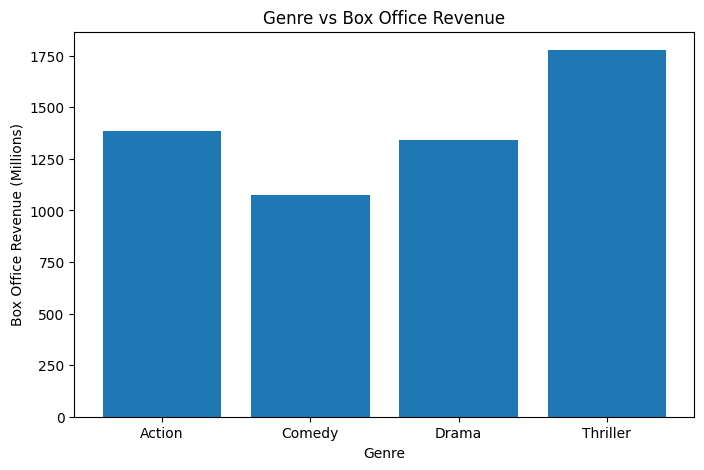

In [48]:
# Create a bar chart showing total revenue by genre
plt.figure(figsize=(8, 5))
plt.bar(genre_revenue.index, genre_revenue.values)
plt.title("Genre vs Box Office Revenue")# Add title
plt.xlabel("Genre")# Label the x-axis
plt.ylabel("Box Office Revenue (Millions)")# Label the y-axis
plt.show()# Display the chart

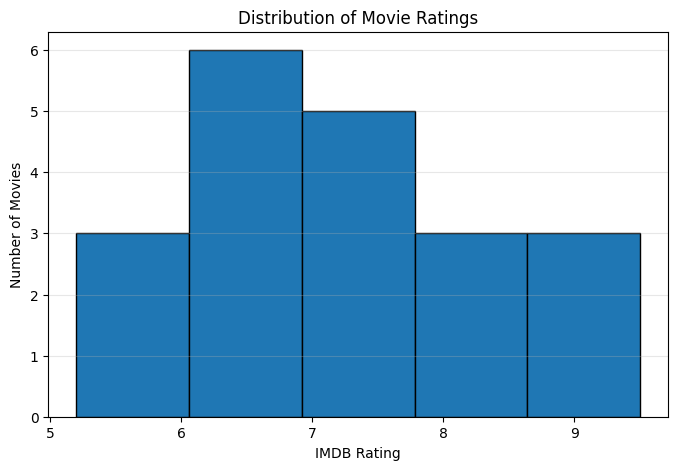

In [49]:
# Create a histogram of IMDB ratings
plt.figure(figsize=(8, 5))
plt.hist(df["IMDB_Rating"], bins=5, edgecolor="black")
plt.title("Distribution of Movie Ratings")# Add title
plt.xlabel("IMDB Rating")# Label x-axis
plt.ylabel("Number of Movies")# Label y-axis
plt.grid(axis="y", alpha=0.3)# Add grid for easier reading
plt.show()# Display the histogram

In [50]:
# Create a new column called 'Hit'
df["Hit"] = df["IMDB_Rating"] >= 8
# A movie is considered a hit if its IMDB rating is 8 or higher
df.head()# Display the updated dataset

,Movie_ID,Genre,Duration_Minutes,IMDB_Rating,Box_Office_Millions,Hit
0,4001,Thriller,168,6.8,77.3,False
1,4002,Thriller,155,6.1,132.1,False
2,4003,Action,125,7.8,276.1,False
3,4004,Comedy,177,9.5,437.8,True
4,4005,Action,98,6.2,222.4,False


In [51]:
# Count the number of hit movies
hit_count = df["Hit"].sum()
print("Total number of Hit movies:", hit_count)

Total number of Hit movies: 5


In [52]:
# Calculate the percentage of movies that are hits
hit_percentage = df["Hit"].mean() * 100
print("Percentage of Hit movies:", hit_percentage, "%")

Percentage of Hit movies: 25.0 %
